<a href="https://colab.research.google.com/github/JotiNARINDER/ecg-arrhythmia-classification/blob/main/ECG_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 40.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


In [4]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print ("tout est installé")

tout est installé


In [6]:
!pip install wfdb -q
print(" wfdb installé")

 wfdb installé


In [7]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

print(" Toutes les librairies importées")

 Toutes les librairies importées


In [8]:
# Téléchargement dataset depuis PhysioNet
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

print(f"Signal chargé")
print(f"Fréquence d'échantillonnage : {record.fs} Hz")
print(f"Durée : {record.sig_len / record.fs / 60:.1f} minutes")
print(f"Nombre de battements annotés : {len(annotation.sample)}")

Signal chargé
Fréquence d'échantillonnage : 360 Hz
Durée : 30.1 minutes
Nombre de battements annotés : 2274


In [9]:
import os

# Télécharger en local dans Colab
wfdb.dl_database('mitdb', dl_dir='./mitdb_data', records=['100', '101', '103'])

# Voir les fichiers téléchargés
for f in os.listdir('./mitdb_data'):
    print(f)

Generating record list for: 100
Generating record list for: 101
Generating record list for: 103
Generating list of all files for: 100
Generating list of all files for: 101
Generating list of all files for: 103
Created local base download directory: ./mitdb_data
Finished downloading files
103.atr
100.hea
101.hea
103.hea
100.dat
101.atr
101.dat
103.dat
100.atr


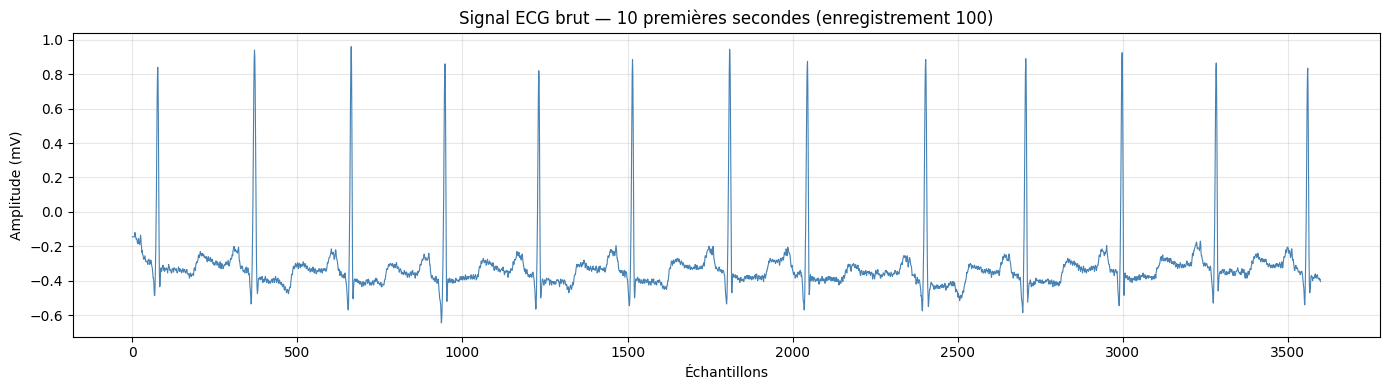

In [10]:
record = wfdb.rdrecord('./mitdb_data/100')
annotation = wfdb.rdann('./mitdb_data/100', 'atr')

fs = record.fs
signal = record.p_signal[:, 0]

plt.figure(figsize=(14, 4))
plt.plot(signal[:fs*10], color='steelblue', linewidth=0.8)
plt.title("Signal ECG brut — 10 premières secondes (enregistrement 100)")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude (mV)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# j'affiche les 20 premiers battements et leur label
print("Positions des battements et leur type :")
print(f"{'Index':<8} {'Position':<12} {'Label':<10} {'Signification'}")
print("-" * 50)

signification = {
    'N': 'Normal',
    'L': 'Bloc branche gauche',
    'R': 'Bloc branche droite',
    'V': 'Battement ventriculaire',
    'A': 'Battement auriculaire',
    'F': 'Fusion',
    '/': 'Pacemaker'
}

for i in range(20):
    sym = annotation.symbol[i]
    pos = annotation.sample[i]
    sig = signification.get(sym, 'Autre')
    print(f"{i:<8} {pos:<12} {sym:<10} {sig}")

Positions des battements et leur type :
Index    Position     Label      Signification
--------------------------------------------------
0        18           +          Autre
1        77           N          Normal
2        370          N          Normal
3        662          N          Normal
4        946          N          Normal
5        1231         N          Normal
6        1515         N          Normal
7        1809         N          Normal
8        2044         A          Battement auriculaire
9        2402         N          Normal
10       2706         N          Normal
11       2998         N          Normal
12       3282         N          Normal
13       3560         N          Normal
14       3862         N          Normal
15       4170         N          Normal
16       4466         N          Normal
17       4764         N          Normal
18       5060         N          Normal
19       5346         N          Normal
